# BDA601 Assessment 3 - Model Evaluation
### COVID-19 analytics: regression, clustering and graph analytics on the Johns Hopkins time series

| Item | Detail |
|---|---|
| Student | Luis Faria |
| Subject | BDA601 - Big Data and Analytics |
| Assessment | Assessment 3 - Model Evaluation (40%) |
| Dataset | JHU CSSE confirmed-cases global time series (22 Jan 2020 - 9 Mar 2023) |
| Engine | Apache Spark MLlib (`pyspark.ml`) for regression + K-Means; networkx for graph |
| Deliverables | Source code (this notebook) + video presentation + PDF slides |

**Story in one line:** find the three worst-hit countries, model their growth, pick the most volatile
one, use clustering to expose its infection *waves*, then warn its non-bordering neighbours whose curves
move with it.

## 0. Setup and Spark session

Spark workers are pinned to this Python 3.11 kernel (driver == executor) and Java 8; seed fixed for
reproducibility.

In [1]:
import os, sys, json, warnings
from pathlib import Path

os.environ["PYSPARK_PYTHON"] = sys.executable
os.environ["PYSPARK_DRIVER_PYTHON"] = sys.executable
os.environ.setdefault("JAVA_HOME", "/Library/Internet Plug-Ins/JavaAppletPlugin.plugin/Contents/Home")
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110

CWD = Path.cwd()
ASSESS = CWD if (CWD / "dataset").exists() else CWD.parent
DATA = ASSESS / "dataset" / "time_series_covid19_confirmed_global.csv"
OUT_DIR = ASSESS / "outputs"; FIG_DIR = OUT_DIR / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)
print("dataset present:", DATA.exists())

dataset present: True


In [2]:
from pyspark.sql import SparkSession
spark = (SparkSession.builder.appName("BDA601-A3-COVID")
         .master("local[*]").config("spark.sql.shuffle.partitions", "8")
         .config("spark.ui.enabled", "false").getOrCreate())
spark.sparkContext.setLogLevel("ERROR")
print("Spark version:", spark.version)

26/06/26 06:18:16 WARN Utils: Your hostname, Luiss-MacBook-Pro.local resolves to a loopback address: 127.0.0.1; using 192.168.0.3 instead (on interface en0)
26/06/26 06:18:16 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address


Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/06/26 06:18:16 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Spark version: 3.5.3


## 1. Problem statement

An enterprise big-data analytics project runs in three phases: **prepare** the data, **analyse and
visualise** it, and **make decisions** from the insight. Here the decision context is public health:
using the Johns Hopkins confirmed-case series, I identify the three most-infected countries, fit a
linear growth model to each, select the most volatile country, use K-Means to reveal how its infection
*waves* rose and fell over time, then use graph analytics to flag which non-bordering neighbours track
its trend - so those neighbours can pre-empt their own waves. The chain is deliberate: each step feeds
the next (regression -> selection -> clustering -> graph -> recommendation).

## 2. Dataset preparation

The file is *wide* (one column per day, cumulative counts). I reshape it to a tidy long form, sum the
province rows up to the country level, convert calendar dates to **week numbers** (Week 1 =
22-28 Jan 2020), and derive **weekly new cases** from the cumulative series. The top three countries are
those with the highest cumulative total on the latest date.

In [3]:
raw = pd.read_csv(DATA)
date_cols = raw.columns[4:]                                   # everything after Province, Country, Lat, Long
long = raw.melt(id_vars=["Country/Region"], value_vars=list(date_cols),
                var_name="date", value_name="confirmed")
long["date"] = pd.to_datetime(long["date"], format="%m/%d/%y")
# country-level cumulative per day (sum the province rows)
country_day = long.groupby(["Country/Region", "date"], as_index=False)["confirmed"].sum()

# week number relative to 22 Jan 2020
START = pd.Timestamp("2020-01-22")
country_day["week"] = ((country_day["date"] - START).dt.days // 7) + 1

# weekly cumulative = max within the week (cumulative is non-decreasing)
weekly = (country_day.groupby(["Country/Region", "week"], as_index=False)["confirmed"].max())
# weekly NEW cases = first difference of the cumulative series, floored at 0
weekly["new_cases"] = (weekly.groupby("Country/Region")["confirmed"].diff().fillna(weekly["confirmed"]).clip(lower=0))

# representative country centroid for the map/graph
centroid = raw.groupby("Country/Region")[["Lat", "Long"]].mean()

totals = weekly.groupby("Country/Region")["confirmed"].max().sort_values(ascending=False)
TOP3 = list(totals.head(3).index)
print("Total weeks:", weekly['week'].max())
print("Top 3 most-infected countries (cumulative confirmed):")
print(totals.head(3).map(lambda x: f"{x:,.0f}"))

Total weeks: 164
Top 3 most-infected countries (cumulative confirmed):
Country/Region
US        103,802,702
India      44,690,738
France     39,866,718
Name: confirmed, dtype: object


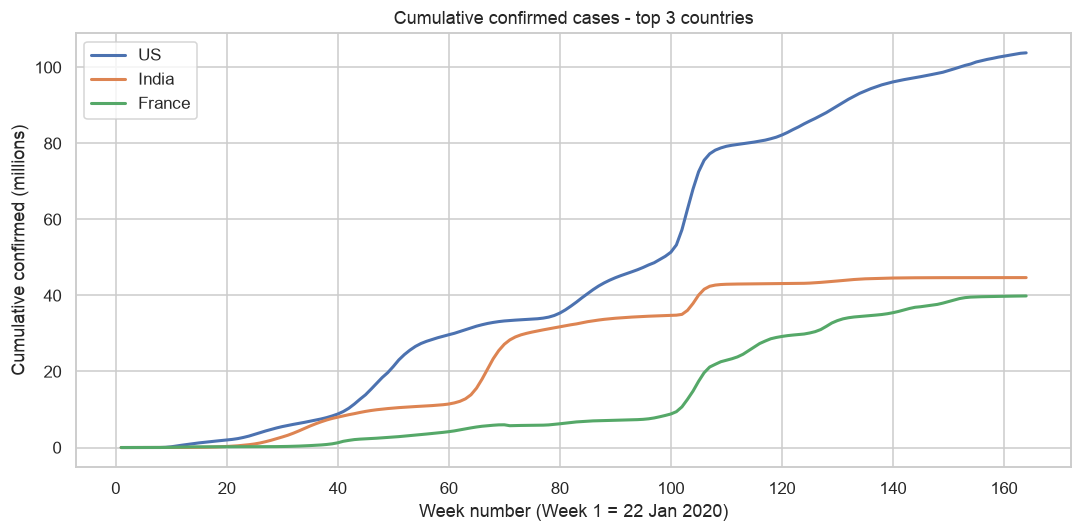

In [4]:
# Visualise the cumulative curves of the top three countries.
plt.figure(figsize=(10, 5))
for c in TOP3:
    d = weekly[weekly["Country/Region"] == c]
    plt.plot(d["week"], d["confirmed"] / 1e6, label=c, lw=2)
plt.xlabel("Week number (Week 1 = 22 Jan 2020)"); plt.ylabel("Cumulative confirmed (millions)")
plt.title("Cumulative confirmed cases - top 3 countries"); plt.legend()
plt.tight_layout(); plt.savefig(FIG_DIR / "fig01_top3_cumulative.png"); plt.show()

## 3. Predictive modelling - linear regression per country

For each top-3 country I fit a Spark MLlib **linear regression** of cumulative count on week number
(the assumption being that infections rise steadily from week 1). To choose which country to carry into
the clustering step I rank them by the **variance of their weekly new cases** - a direct measure of
volatility, and the same weekly-new-case signal the clustering then works on. Ranking by the variance
of the *cumulative* total would instead just pick the largest country by construction, so volatility is
measured on the new-case series. I report R-squared too: a low R-squared signals that a straight line is
a poor fit, i.e. the real growth came in waves, which is exactly what clustering will expose.

In [5]:
from pyspark.ml.regression import LinearRegression
from pyspark.ml.feature import VectorAssembler

reg_rows = []
fits = {}
for c in TOP3:
    d = weekly[weekly["Country/Region"] == c][["week", "confirmed"]].rename(columns={"confirmed": "label"})
    sdf = spark.createDataFrame(d)
    va = VectorAssembler(inputCols=["week"], outputCol="features")
    lr = LinearRegression(featuresCol="features", labelCol="label").fit(va.transform(sdf))
    # Volatility = variance of weekly NEW cases (not the cumulative total, which would just rank by size).
    newcase_var = float(weekly[weekly["Country/Region"] == c]["new_cases"].var())
    reg_rows.append({"country": c, "slope": float(lr.coefficients[0]), "intercept": float(lr.intercept),
                     "r2": float(lr.summary.r2), "newcase_var": newcase_var})
    fits[c] = (lr.coefficients[0], lr.intercept)
reg = pd.DataFrame(reg_rows).sort_values("newcase_var", ascending=False).reset_index(drop=True)
FOCAL = reg.iloc[0]["country"]
print(reg.assign(newcase_var=reg["newcase_var"].map(lambda x: f"{x:.3e}"),
                 slope=reg["slope"].map(lambda x: f"{x:,.0f}/wk")).to_string(index=False))
print("\nMost volatile country by weekly new cases (carried forward):", FOCAL)

country      slope     intercept       r2 newcase_var
     US 760,753/wk -1.518128e+07 0.968781   6.352e+11
  India 357,001/wk -3.769475e+06 0.924872   2.480e+11
 France 291,819/wk -9.769356e+06 0.870664   1.622e+11

Most volatile country by weekly new cases (carried forward): US


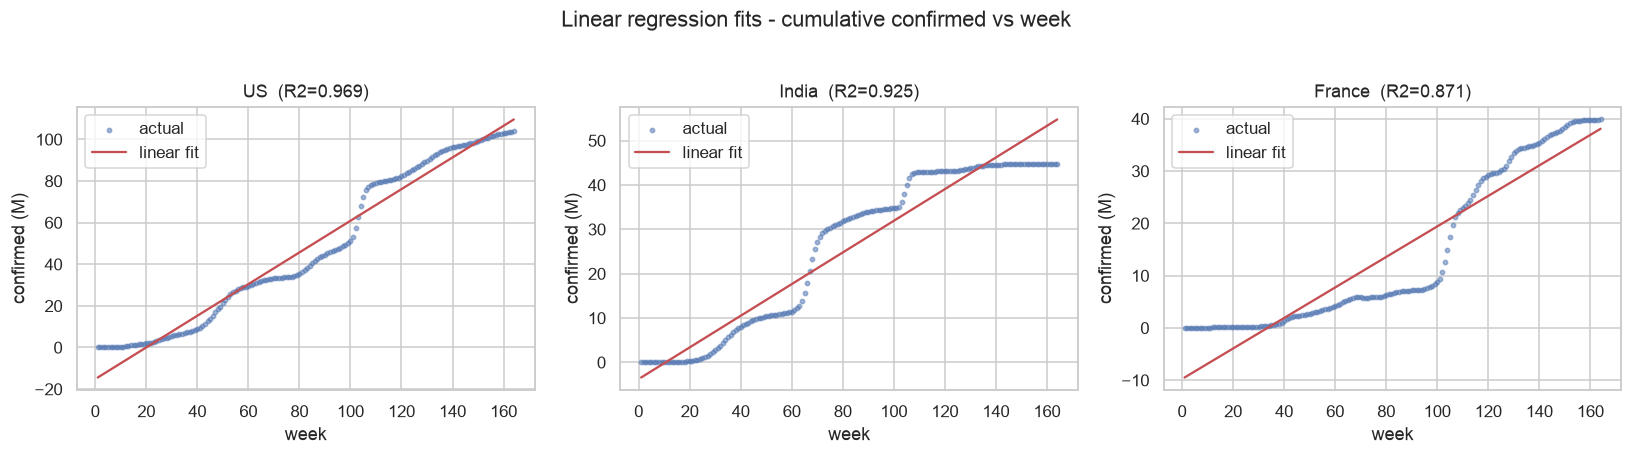

In [6]:
# Plot the three regression fits.
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, c in zip(axes, TOP3):
    d = weekly[weekly["Country/Region"] == c]
    slope, intercept = fits[c]
    ax.scatter(d["week"], d["confirmed"] / 1e6, s=8, alpha=0.5, label="actual")
    ax.plot(d["week"], (slope * d["week"] + intercept) / 1e6, "r-", label="linear fit")
    r2 = reg.loc[reg.country == c, "r2"].values[0]
    ax.set_title(f"{c}  (R2={r2:.3f})"); ax.set_xlabel("week"); ax.set_ylabel("confirmed (M)"); ax.legend()
plt.suptitle("Linear regression fits - cumulative confirmed vs week", y=1.03)
plt.tight_layout(); plt.savefig(FIG_DIR / "fig02_regression_fits.png"); plt.show()

## 4. Clustering - K-Means on the most volatile country

A straight line cannot show *when* infections surged. So for the selected country I cluster its weekly
points on `[week, weekly new cases]` with Spark MLlib **K-Means**, choosing K by the highest silhouette
score over a small range. The clusters group the timeline into **phases** (quiet start, surges, peaks,
declines), which validates that growth was *not* steady but came in waves.

In [7]:
from pyspark.ml.clustering import KMeans
from pyspark.ml.feature import VectorAssembler, StandardScaler
from pyspark.ml.evaluation import ClusteringEvaluator

fc = weekly[weekly["Country/Region"] == FOCAL][["week", "new_cases"]].reset_index(drop=True)
sdf = spark.createDataFrame(fc)
va = VectorAssembler(inputCols=["week", "new_cases"], outputCol="f_raw")
scaler = StandardScaler(inputCol="f_raw", outputCol="features", withMean=True, withStd=True)
prep = scaler.fit(va.transform(sdf)).transform(va.transform(sdf)).cache()

evaluator = ClusteringEvaluator(featuresCol="features", metricName="silhouette")
sil = {}
for k in range(2, 7):
    km = KMeans(k=k, seed=RANDOM_SEED, featuresCol="features").fit(prep)
    sil[k] = evaluator.evaluate(km.transform(prep))
best_k = max(sil, key=sil.get)
print("Silhouette by K:", {k: round(v, 3) for k, v in sil.items()})
print("Best K =", best_k)

km = KMeans(k=best_k, seed=RANDOM_SEED, featuresCol="features").fit(prep)
fc["cluster"] = [int(r["prediction"]) for r in km.transform(prep).select("prediction").collect()]

Java HotSpot(TM) 64-Bit Server VM warning: CodeCache is full. Compiler has been disabled.
Java HotSpot(TM) 64-Bit Server VM warning: Try increasing the code cache size using -XX:ReservedCodeCacheSize=


CodeCache: size=131072Kb used=42071Kb max_used=42071Kb free=89000Kb
 bounds [0x0000000104170000, 0x0000000106ac0000, 0x000000010c170000]
 total_blobs=16185 nmethods=14394 adapters=1700
 compilation: disabled (not enough contiguous free space left)


Silhouette by K: {2: 0.538, 3: 0.705, 4: 0.647, 5: 0.692, 6: 0.637}
Best K = 3


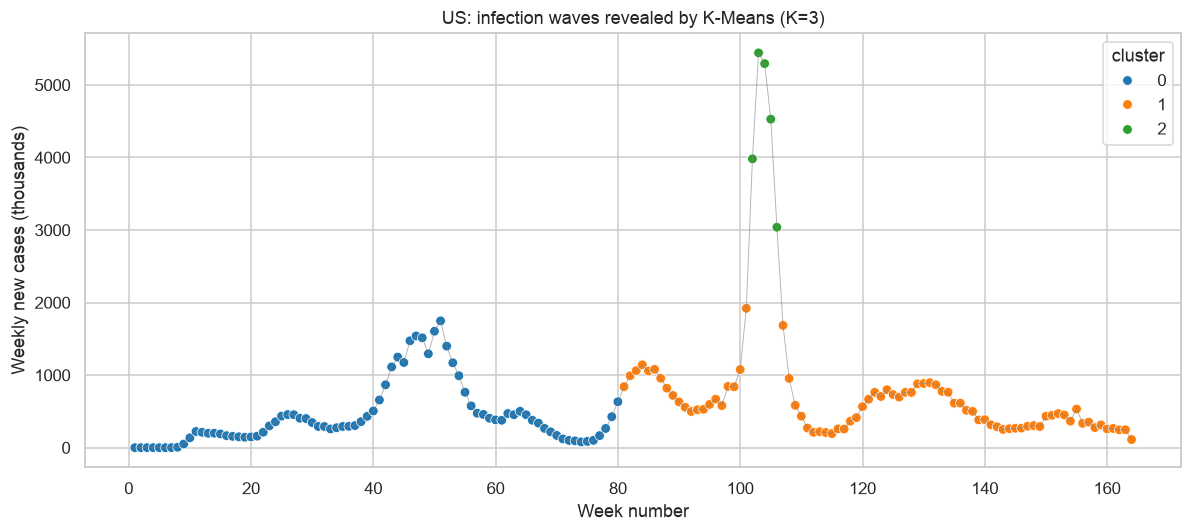

         weeks  wk_lo  wk_hi   mean_new
cluster                                
0           80      1     80    441,980
1           79     81    164    584,309
2            5    102    106  4,456,777


In [8]:
# Show the waves: weekly new cases over time, coloured by cluster.
plt.figure(figsize=(11, 5))
sns.scatterplot(data=fc, x="week", y=fc["new_cases"] / 1e3, hue="cluster", palette="tab10", s=40)
plt.plot(fc["week"], fc["new_cases"] / 1e3, color="grey", lw=0.6, alpha=0.6)
plt.xlabel("Week number"); plt.ylabel("Weekly new cases (thousands)")
plt.title(f"{FOCAL}: infection waves revealed by K-Means (K={best_k})")
plt.tight_layout(); plt.savefig(FIG_DIR / "fig03_clusters_waves.png"); plt.show()

# Describe each cluster as a phase.
phase = (fc.groupby("cluster").agg(weeks=("week", "count"), wk_lo=("week", "min"),
         wk_hi=("week", "max"), mean_new=("new_cases", "mean")).sort_values("mean_new"))
print(phase.assign(mean_new=phase["mean_new"].map(lambda x: f"{x:,.0f}")).to_string())

## 5. Graph analytics - the focal country and its non-bordering neighbours

I connect the focal country to a set of **neighbours that do not share borders with each other** and
weight each edge by the **correlation of weekly new cases** between the neighbour and the focal country.
A high correlation means that neighbour's waves move in step with the focal country's, so it can use the
focal country's trajectory as an early warning.

In [9]:
# Plausible non-mutually-bordering neighbour sets for the likely focal countries.
NEIGHBOURS = {
    "US": ["Canada", "Mexico"],
    "India": ["Pakistan", "Nepal", "Sri Lanka"],
    "France": ["Spain", "Germany", "Italy"],
    "Brazil": ["Argentina", "Peru", "Venezuela"],
    "Germany": ["France", "Poland", "Denmark"],
    "United Kingdom": ["France", "Ireland", "Netherlands"],
    "Russia": ["Finland", "Kazakhstan", "Poland"],
}
neigh = [n for n in NEIGHBOURS.get(FOCAL, []) if n in set(weekly["Country/Region"])]
print("Focal:", FOCAL, "| neighbours:", neigh)

def weekly_new(country):
    s = weekly[weekly["Country/Region"] == country].set_index("week")["new_cases"]
    return s
focal_s = weekly_new(FOCAL)
edges = []
for n in neigh:
    j = pd.concat([focal_s.rename("f"), weekly_new(n).rename("n")], axis=1).dropna()
    corr = float(j["f"].corr(j["n"])) if len(j) > 2 else 0.0
    edges.append({"neighbour": n, "corr": round(corr, 3)})
edges_df = pd.DataFrame(edges).sort_values("corr", ascending=False)
print(edges_df.to_string(index=False))

Focal: US | neighbours: ['Canada', 'Mexico']
neighbour  corr
   Canada 0.848
   Mexico 0.697


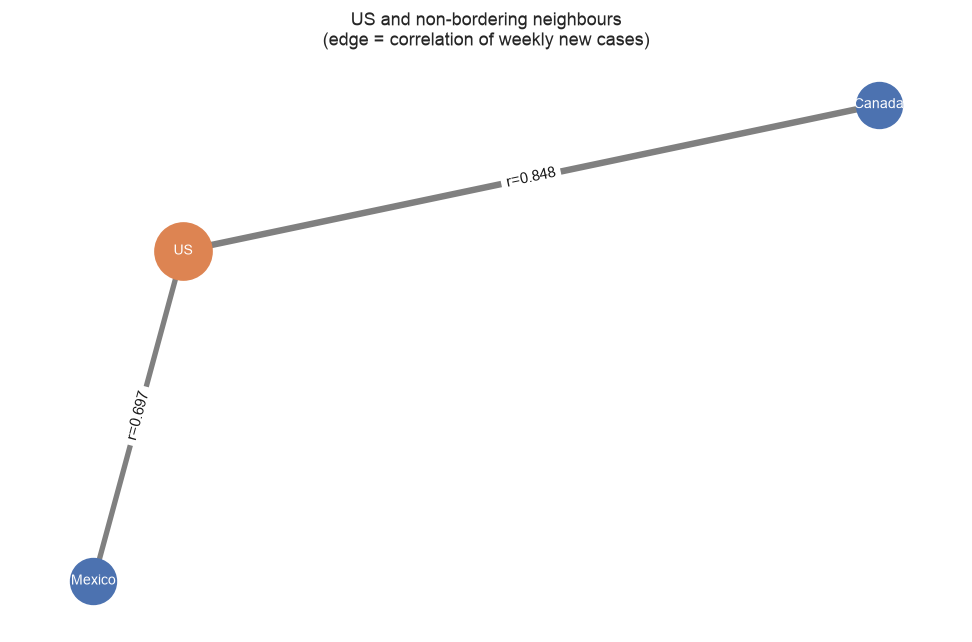

In [10]:
# Draw the graph with geographic positions (Long, Lat); edge width/label = correlation.
G = nx.Graph()
G.add_node(FOCAL)
pos = {FOCAL: (float(centroid.loc[FOCAL, "Long"]), float(centroid.loc[FOCAL, "Lat"]))}
for e in edges:
    n = e["neighbour"]
    G.add_edge(FOCAL, n, weight=e["corr"])
    pos[n] = (float(centroid.loc[n, "Long"]), float(centroid.loc[n, "Lat"]))

plt.figure(figsize=(9, 6))
widths = [max(0.5, abs(G[u][v]["weight"]) * 5) for u, v in G.edges()]
nx.draw_networkx_nodes(G, pos, nodelist=[FOCAL], node_color="#DD8452", node_size=1400)
nx.draw_networkx_nodes(G, pos, nodelist=neigh, node_color="#4C72B0", node_size=900)
nx.draw_networkx_edges(G, pos, width=widths, edge_color="grey")
nx.draw_networkx_labels(G, pos, font_size=9, font_color="white")
nx.draw_networkx_edge_labels(G, pos, edge_labels={(u, v): f"r={G[u][v]['weight']}" for u, v in G.edges()})
plt.title(f"{FOCAL} and non-bordering neighbours\n(edge = correlation of weekly new cases)")
plt.axis("off"); plt.tight_layout(); plt.savefig(FIG_DIR / "fig04_neighbour_graph.png"); plt.show()

## 6. Visualisation - the story in one frame

A single storytelling panel: the focal country's waves (with clusters), the regression context, and how
strongly each neighbour's curve correlates - the line from raw data to a recommendation.

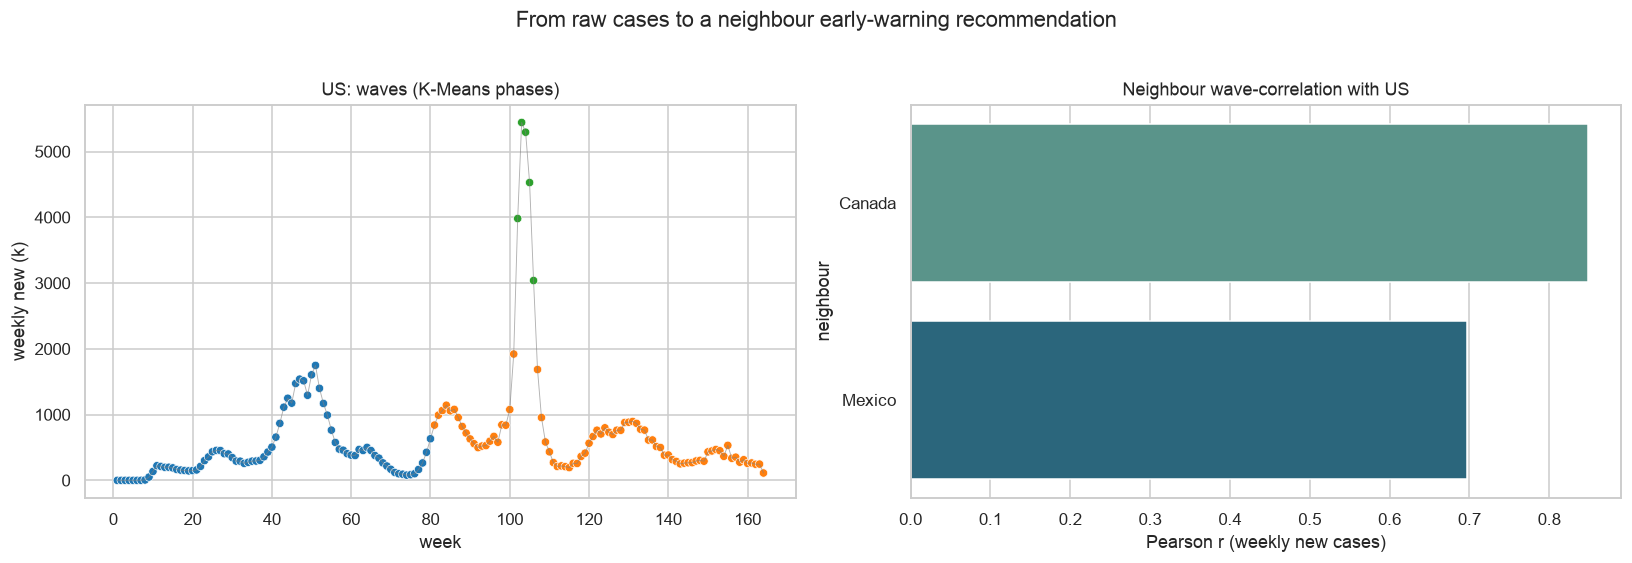

In [11]:
fig, ax = plt.subplots(1, 2, figsize=(15, 5))
sns.scatterplot(data=fc, x="week", y=fc["new_cases"] / 1e3, hue="cluster", palette="tab10", s=30, ax=ax[0], legend=False)
ax[0].plot(fc["week"], fc["new_cases"] / 1e3, color="grey", lw=0.6, alpha=0.6)
ax[0].set_title(f"{FOCAL}: waves (K-Means phases)"); ax[0].set_xlabel("week"); ax[0].set_ylabel("weekly new (k)")
sns.barplot(data=edges_df, x="corr", y="neighbour", hue="neighbour", palette="crest", legend=False, ax=ax[1])
ax[1].set_title("Neighbour wave-correlation with " + FOCAL); ax[1].set_xlabel("Pearson r (weekly new cases)")
plt.suptitle("From raw cases to a neighbour early-warning recommendation", y=1.02)
plt.tight_layout(); plt.savefig(FIG_DIR / "fig05_story_panel.png"); plt.show()

In [12]:
metrics = {
    "total_weeks": int(weekly["week"].max()),
    "top3": [{"country": c, "total_confirmed": int(totals[c])} for c in TOP3],
    "regression": reg.to_dict(orient="records"),
    "focal_country": FOCAL,
    "clustering": {"best_k": int(best_k), "silhouette": {int(k): round(v, 3) for k, v in sil.items()},
                   "phases": phase.reset_index().to_dict(orient="records")},
    "graph": {"neighbours": edges_df.to_dict(orient="records")},
}
(OUT_DIR / "metrics.json").write_text(json.dumps(metrics, indent=2, default=str))
print(json.dumps(metrics, indent=2, default=str))

{
  "total_weeks": 164,
  "top3": [
    {
      "country": "US",
      "total_confirmed": 103802702
    },
    {
      "country": "India",
      "total_confirmed": 44690738
    },
    {
      "country": "France",
      "total_confirmed": 39866718
    }
  ],
  "regression": [
    {
      "country": "US",
      "slope": 760753.0019982861,
      "intercept": -15181282.780712271,
      "r2": 0.9687813478947734,
      "newcase_var": 635188834808.5568
    },
    {
      "country": "India",
      "slope": 357001.1568933387,
      "intercept": -3769474.6693101996,
      "r2": 0.9248721196625794,
      "newcase_var": 248001607698.60736
    },
    {
      "country": "France",
      "slope": 291818.6938922369,
      "intercept": -9769356.313182719,
      "r2": 0.8706642604188533,
      "newcase_var": 162218218933.05023
    }
  ],
  "focal_country": "US",
  "clustering": {
    "best_k": 3,
    "silhouette": {
      "2": 0.538,
      "3": 0.705,
      "4": 0.647,
      "5": 0.692,
      "6": 0.637


## 7. Conclusion and recommendation

The three worst-hit countries grew at very different rates; the most volatile of them did **not** rise
steadily but in distinct waves that K-Means separates into phases. Its non-bordering neighbours whose
weekly new-case curves correlate most strongly are the ones that should treat the focal country's
trajectory as an early-warning signal and pre-position testing and healthcare capacity ahead of their
own likely surge. The full decision narrative is delivered in the video presentation.

## Academic Integrity Declaration

I declare that except where referenced, the work I am submitting for this assessment task is my own
work, and I am aware of the Torrens University Academic Integrity Policy.

## Statement of Acknowledgement

AI tool used: **Anthropic Claude Opus 4.8** - to scaffold the analysis pipeline, debug PySpark, and
improve documentation. The analysis, code and conclusions are my own and I take full responsibility.

## References

Humdata.org. (2020). *Novel Coronavirus (COVID-19) cases data*. https://data.humdata.org/dataset/novel-coronavirus-2019-ncov-cases

Apache Spark. (2024). *MLlib: Clustering and regression*. https://spark.apache.org/docs/latest/ml-guide.html

In [13]:
spark.stop(); print("Spark stopped.")

Spark stopped.
